In [1]:
# ==============================================================================
# 1. SETUP DO EXPERIMENTO E CALIBRAÇÃO DE ATRIBUIÇÕES (τa)
# ==============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Hiperparâmetros metodológicos
N = 500_000   # Tamanho da amostra interna (número de operações por repetição)
R = 40        # Número de repetições globais

# Setup de variáveis residentes usadas como fonte nas atribuições var ← var
b_int = 99
b_flt = 2.71828
b_bool = True

# Coleta e cálculo estatístico
tempos_brutos = {}
tempos_filtrados = {}
cortes_percentil = {}
tabela_resultados = []

def homologar(nome, times_r):
    raw = np.array(times_r)
    tempos_brutos[nome] = raw

    # 1. Métricas Brutas
    mu_b = np.mean(raw)
    sigma_b = np.std(raw, ddof=1)
    cv_b = sigma_b / mu_b

    # 2. Filtragem por Percentil (cortando 5% e 95%) — técnica robusta (imune à magnitude dos outliers)
    p5 = np.percentile(raw, 5)
    p95 = np.percentile(raw, 95)
    cortes_percentil[nome] = (p5, p95)

    fil = raw[(raw >= p5) & (raw <= p95)]
    tempos_filtrados[nome] = fil

    # 3. Métricas Filtradas
    mu_f = np.mean(fil)
    sigma_f = np.std(fil, ddof=1)
    cv_f = sigma_f / mu_f

    tabela_resultados.append({
        "Operação e Tipagem Exata": nome,
        "µbruta (s)": f"{mu_b:.4e}",
        "σbruta (s)": f"{sigma_b:.4e}",
        "CVbruto": f"{cv_b:.4f}",
        "µfil(τa) (s)": f"{mu_f:.4e}",
        "σfil (s)": f"{sigma_f:.4e}",
        "CVfil": f"{cv_f:.4f}",
        "< 0.15": "Sim" if cv_f < 0.15 else "Não"
    })

print("Executando calibração de atribuições (τa)...")

# ------------------------------------------------------------------------------
# Primitiva: var_int ← cte_int (ex: a = 5)
# Medida com a atribuição direta no loop cronometrado, sem chamada de função
# isolando a primitiva (uma chamada extra inseriria ruído de overhead de call).
# ------------------------------------------------------------------------------
times_r = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        a = 5
    t1 = time.perf_counter()
    times_r.append((t1 - t0) / N)
homologar("var_int ← cte_int (ex: a = 5)", times_r)

# ------------------------------------------------------------------------------
# Primitiva: var_float ← cte_float
# ------------------------------------------------------------------------------
times_r = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        a = 3.14159
    t1 = time.perf_counter()
    times_r.append((t1 - t0) / N)
homologar("var_float ← cte_float", times_r)

# ------------------------------------------------------------------------------
# Primitiva: var_bool ← cte_bool
# ------------------------------------------------------------------------------
times_r = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        a = True
    t1 = time.perf_counter()
    times_r.append((t1 - t0) / N)
homologar("var_bool ← cte_bool", times_r)

# ------------------------------------------------------------------------------
# Primitiva: var_int ← var_int (ex: a = b)
# ------------------------------------------------------------------------------
times_r = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        a = b_int
    t1 = time.perf_counter()
    times_r.append((t1 - t0) / N)
homologar("var_int ← var_int (ex: a = b)", times_r)

# ------------------------------------------------------------------------------
# Primitiva: var_float ← var_float
# ------------------------------------------------------------------------------
times_r = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        a = b_flt
    t1 = time.perf_counter()
    times_r.append((t1 - t0) / N)
homologar("var_float ← var_float", times_r)

# Exibição da Matriz de Calibração homologada
df_tau_a = pd.DataFrame(tabela_resultados)
print("\n--- 4.1. MATRIZ DE CALIBRAÇÃO (τa) ---")
display(df_tau_a)


Executando calibração de atribuições (τa)...

--- 4.1. MATRIZ DE CALIBRAÇÃO (τa) ---


,Operação e Tipagem Exata,µbruta (s),σbruta (s),CVbruto,µfil(τa) (s),σfil (s),CVfil,< 0.15
0,var_int ← cte_int (ex: a = 5),2.3276e-08,2.1371e-09,0.0918,2.2972e-08,1.4498e-09,0.0631,Sim
1,var_float ← cte_float,2.2879e-08,8.2933e-10,0.0362,2.2812e-08,6.4056e-10,0.0281,Sim
2,var_bool ← cte_bool,2.2746e-08,6.4361e-10,0.0283,2.2667e-08,4.1329e-10,0.0182,Sim
3,var_int ← var_int (ex: a = b),2.6773e-08,5.8070e-10,0.0217,2.6716e-08,3.2431e-10,0.0121,Sim
4,var_float ← var_float,2.7342e-08,1.3187e-09,0.0482,2.7181e-08,9.3544e-10,0.0344,Sim


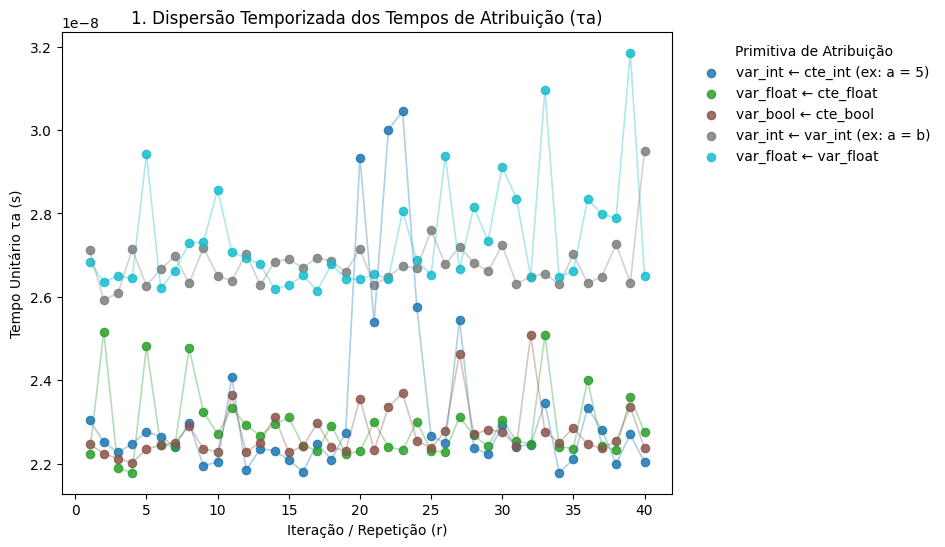

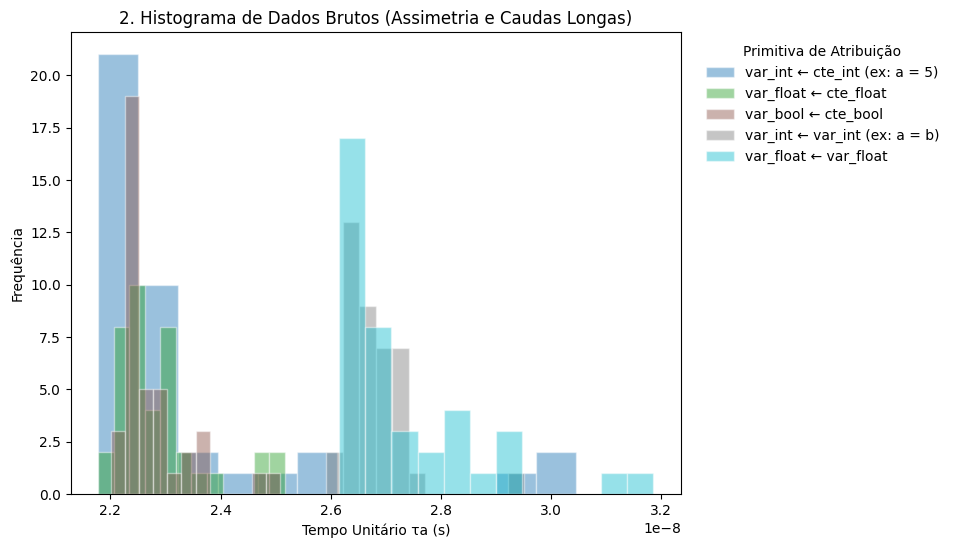

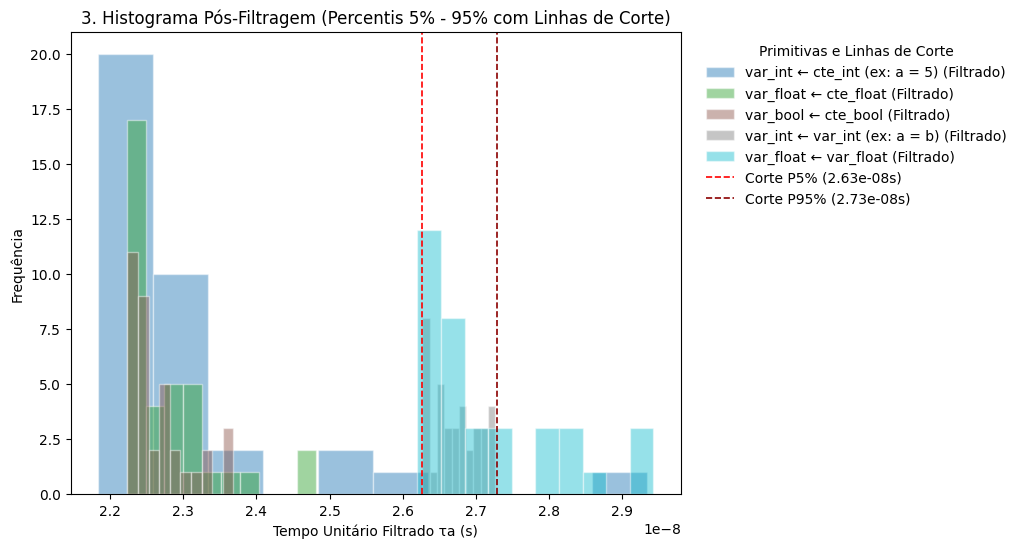

In [2]:
# ==============================================================================
# 2. PAINEL GRÁFICO DE ESTABILIDADE (SEÇÃO 3 DO RELATÓRIO)
# ==============================================================================

cores_op = {nome: cor for nome, cor in zip(tempos_brutos.keys(), plt.cm.tab10(np.linspace(0, 1, len(tempos_brutos))))}
reps = np.arange(1, R + 1)

# ------------------------------------------------------------------------------
# 1) Gráfico de Dispersão Temporizada: r vs Tempo Acumulado / Unitário
# Evidencia a variabilidade temporal e picos anômalos (SO / Garbage Collector)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for nome in tempos_brutos.keys():
    ax.scatter(reps, tempos_brutos[nome], color=cores_op[nome], label=nome, alpha=0.85, s=35)
    ax.plot(reps, tempos_brutos[nome], color=cores_op[nome], alpha=0.35, lw=1.2)

ax.set_xlabel("Iteração / Repetição (r)")
ax.set_ylabel("Tempo Unitário τa (s)")
ax.set_title("1. Dispersão Temporizada dos Tempos de Atribuição (τa)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Primitiva de Atribuição")
fig.subplots_adjust(right=0.68)
plt.show()

# ------------------------------------------------------------------------------
# 2) Histograma de Dados Brutos
# Mostra assimetria e caudas longas causadas por ruído sistêmico
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for nome in tempos_brutos.keys():
    ax.hist(tempos_brutos[nome], bins=12, alpha=0.45, color=cores_op[nome], label=nome, edgecolor="white")

ax.set_xlabel("Tempo Unitário τa (s)")
ax.set_ylabel("Frequência")
ax.set_title("2. Histograma de Dados Brutos (Assimetria e Caudas Longas)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Primitiva de Atribuição")
fig.subplots_adjust(right=0.68)
plt.show()

# ------------------------------------------------------------------------------
# 3) Histograma Pós-Filtragem (Percentil 5% e 95%)
# Mostra a distribuição após filtro com linhas de corte visíveis
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for nome in tempos_brutos.keys():
    ax.hist(tempos_filtrados[nome], bins=10, alpha=0.45, color=cores_op[nome], label=f"{nome} (Filtrado)", edgecolor="white")

# Linha de corte de exemplo para evidenciar visualmente o corte do percentil
op_exemplo = "var_int ← var_int (ex: a = b)"
p5, p95 = cortes_percentil[op_exemplo]
ax.axvline(p5, color="red", ls="--", lw=1.2, label=f"Corte P5% ({p5:.2e}s)")
ax.axvline(p95, color="darkred", ls="--", lw=1.2, label=f"Corte P95% ({p95:.2e}s)")

ax.set_xlabel("Tempo Unitário Filtrado τa (s)")
ax.set_ylabel("Frequência")
ax.set_title("3. Histograma Pós-Filtragem (Percentis 5% - 95% com Linhas de Corte)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Primitivas e Linhas de Corte")
fig.subplots_adjust(right=0.68)
plt.show()


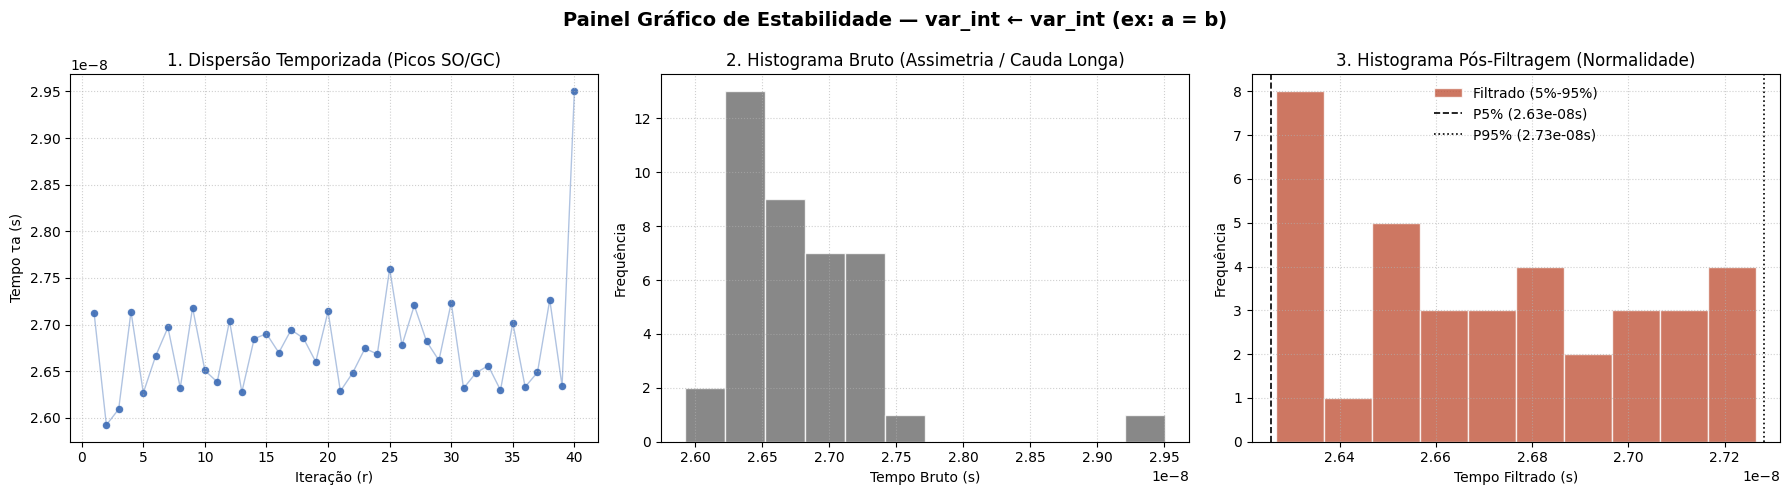

In [3]:
# ==============================================================================
# 3. PAINEL INTEGRADO 1x3 PARA ANEXAR NO RELATÓRIO (EXIGÊNCIA SEÇÃO 3)
# ==============================================================================
# Gera o painel de 3 gráficos para uma primitiva representativa (ou para todas)

def plot_painel_primitiva(nome_primitiva):
    raw = tempos_brutos[nome_primitiva]
    fil = tempos_filtrados[nome_primitiva]
    p5, p95 = cortes_percentil[nome_primitiva]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Painel Gráfico de Estabilidade — {nome_primitiva}", fontsize=14, fontweight="bold")

    # 1. Dispersão Temporizada
    axes[0].scatter(reps, raw, color="#3B6BB5", s=40, edgecolor="white", alpha=0.9)
    axes[0].plot(reps, raw, color="#3B6BB5", alpha=0.4, lw=1)
    axes[0].set_xlabel("Iteração (r)")
    axes[0].set_ylabel("Tempo τa (s)")
    axes[0].set_title("1. Dispersão Temporizada (Picos SO/GC)")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # 2. Histograma Bruto
    axes[1].hist(raw, bins=12, color="#6B6B6B", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Tempo Bruto (s)")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("2. Histograma Bruto (Assimetria / Cauda Longa)")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    # 3. Histograma Pós-Filtragem
    axes[2].hist(fil, bins=10, color="#C1553B", edgecolor="white", alpha=0.8, label="Filtrado (5%-95%)")
    axes[2].axvline(p5, color="black", ls="--", lw=1.2, label=f"P5% ({p5:.2e}s)")
    axes[2].axvline(p95, color="black", ls=":", lw=1.2, label=f"P95% ({p95:.2e}s)")
    axes[2].set_xlabel("Tempo Filtrado (s)")
    axes[2].set_ylabel("Frequência")
    axes[2].set_title("3. Histograma Pós-Filtragem (Normalidade)")
    axes[2].legend(frameon=False)
    axes[2].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

# Exemplo: Painel de 3 gráficos para Atribuição var_int ← var_int
plot_painel_primitiva("var_int ← var_int (ex: a = b)")
